## Set Up Your Data Science Toolkit & Explore Your First Dataset

In [16]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [17]:
df = sns.load_dataset('titanic')

In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [20]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [22]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

### Data Story

The Titanic dataset contains 891 passengers and 12 columns, including the target variable `Survived`.
The dataset contains both numerical and categorical features describing passengers and their travel information.
There are missing values in `Age` (177), `deck` (688),`embark_town` (2) and `Embarked` (2).
`deck` has a particularly large number of missing values, so it may require special handling during preprocessing.
The numerical features include `Age`, `Fare`, `SibSp`, and `Parch`, while features such as `Sex`, `Embarked`, and `deck` are categorical.
This initial exploration shows that missing-value handling and categorical encoding will be important steps before building a machine learning model.

## Clean & Visualize Real-World Data

In [23]:
# Fill missing Age values with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing Embarked values with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Drop Deck because of excessive missing values
df = df.drop(columns=["deck"])

# Check missing values again
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [26]:
# Fill missing values in embark_town with the most frequent value
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Check missing values again
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

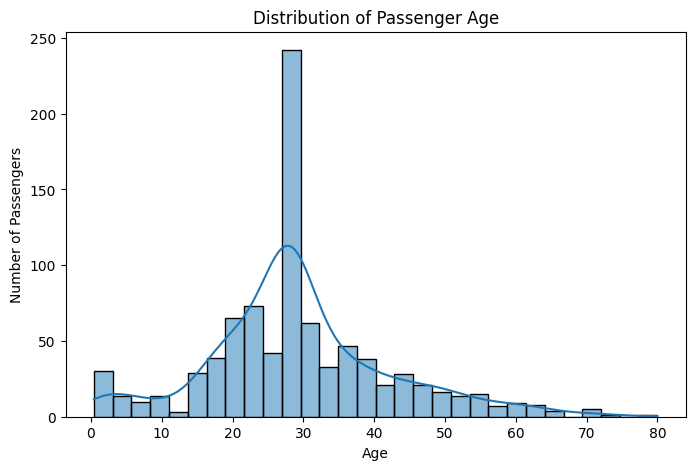

In [24]:
# Histogram 

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Boxplot — Outlier Detection

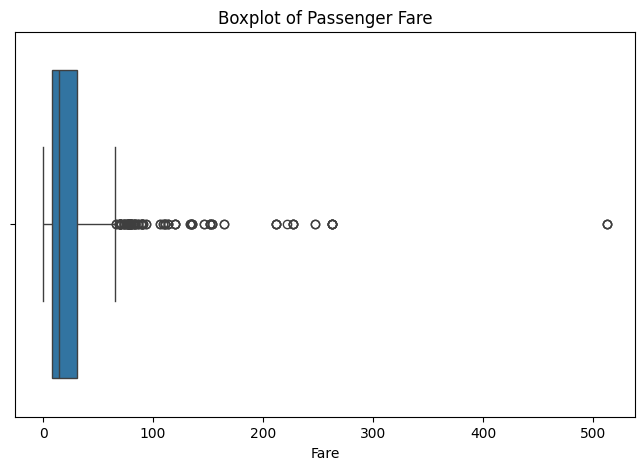

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="fare")

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")

plt.show()


## Bar Chart - Survival by Gender

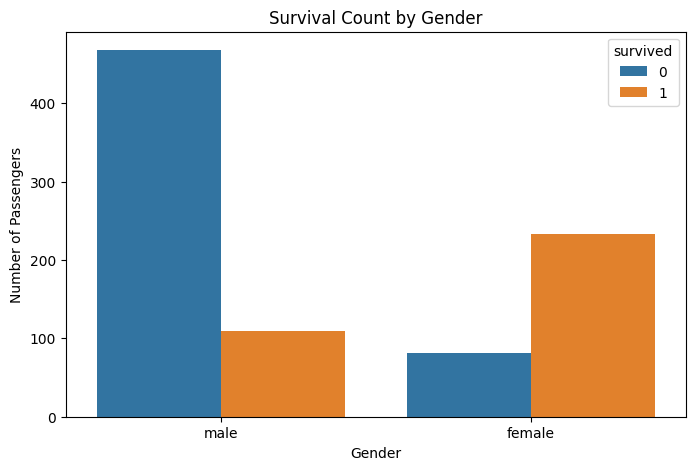

In [27]:
# Bar Chart - Survival by Gender

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

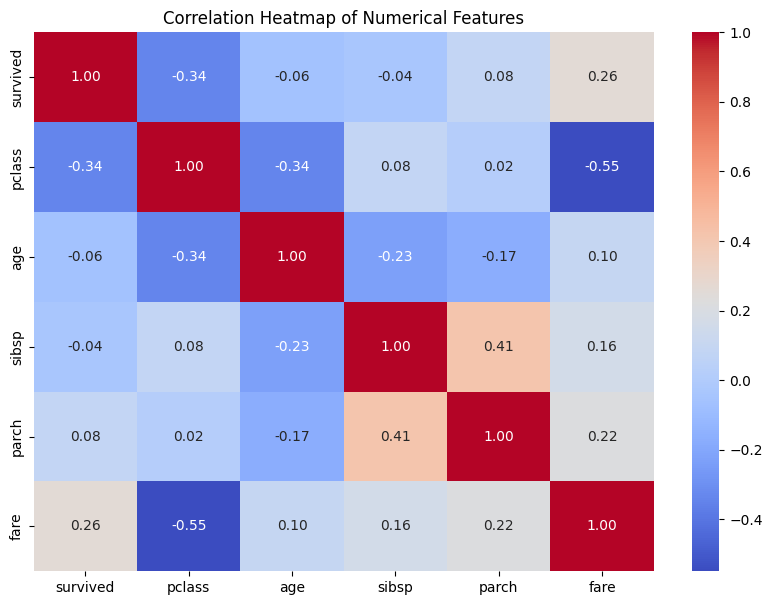

In [28]:
# Correlation Heatmap

plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

## Which feature do you think most affects survival, and why?
I believe `sex` is one of the features that most strongly affects
survival. The bar chart shows a clear difference between male and
female passengers, with females having a much higher survival rate
than males. This may be related to the historical practice of
prioritizing women and children during evacuation. `pclass` also
appears to be an important feature because passengers in higher
classes generally had better survival rates.